In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [3]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kagglehub]━ 1/3 [kagglesdk]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [4]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("shwetabh123/mall-customers")
print("Downloaded to:", path)

# Find the CSV file
csv_file = os.path.join(path, "Mall_Customers.csv")
df = pd.read_csv(csv_file)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

100%|██████████████████████████████████████| 1.56k/1.56k [00:00<00:00, 1.21MB/s]

Extracting files...
Downloaded to: /Users/prathameshbhavsar/.cache/kagglehub/datasets/shwetabh123/mall-customers/versions/1
Shape: (200, 5)

Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Basic stats:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


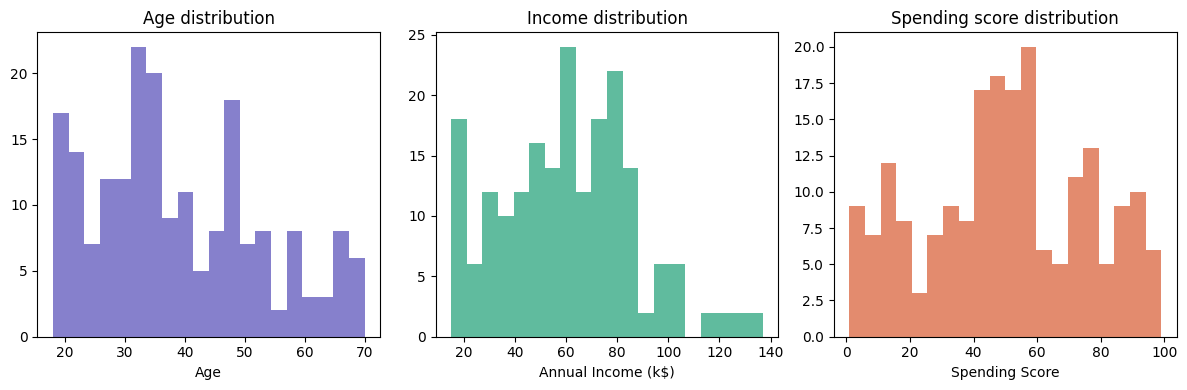

In [5]:
print("Basic stats:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

# Quick look at distributions
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(df['Age'], bins=20, color='#534AB7', alpha=0.7)
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

axes[1].hist(df['Annual Income (k$)'], bins=20, color='#1D9E75', alpha=0.7)
axes[1].set_title('Income distribution')
axes[1].set_xlabel('Annual Income (k$)')

axes[2].hist(df['Spending Score (1-100)'], bins=20, color='#D85A30', alpha=0.7)
axes[2].set_title('Spending score distribution')
axes[2].set_xlabel('Spending Score')

plt.tight_layout()
plt.show()

In [6]:
# Select features for clustering
# We'll use Income and Spending Score first — most intuitive
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale features — CRITICAL for K-means
# Without this, income (0-150) dominates spending score (0-100)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data range:")
print(f"  Income:        {X[:,0].min():.0f} to {X[:,0].max():.0f}")
print(f"  Spending score:{X[:,1].min():.0f} to {X[:,1].max():.0f}")

print("\nScaled data range:")
print(f"  Income:        {X_scaled[:,0].min():.2f} to {X_scaled[:,0].max():.2f}")
print(f"  Spending score:{X_scaled[:,1].min():.2f} to {X_scaled[:,1].max():.2f}")
print("\nNow both features on same scale!")

Original data range:
  Income:        15 to 137
  Spending score:1 to 99

Scaled data range:
  Income:        -1.74 to 2.92
  Spending score:-1.91 to 1.89

Now both features on same scale!


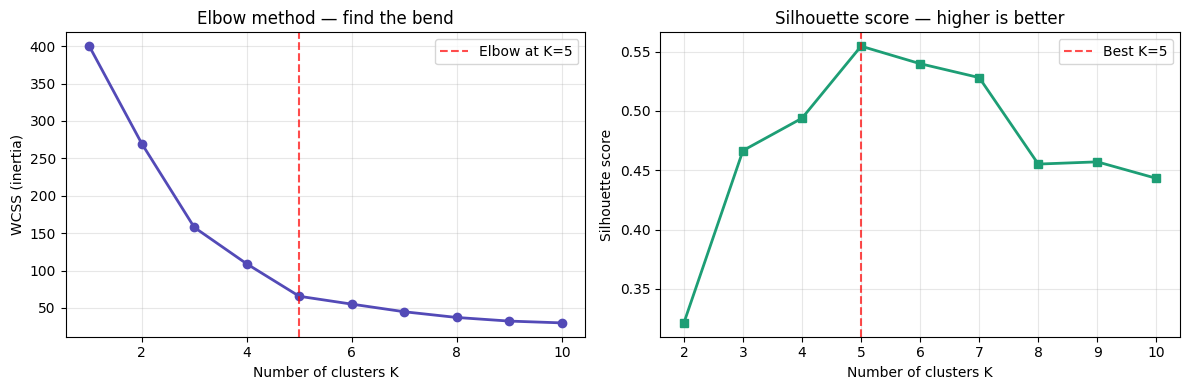


Elbow method suggests: K=5
Silhouette method suggests: K=5 (score=0.5547)


In [7]:
# Try K from 1 to 10 and record WCSS (within-cluster sum of squares)
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot both methods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow curve
ax1.plot(range(1, 11), wcss, 'o-', color='#534AB7', linewidth=2)
ax1.set_xlabel('Number of clusters K')
ax1.set_ylabel('WCSS (inertia)')
ax1.set_title('Elbow method — find the bend')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Elbow at K=5')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Silhouette scores
ax2.plot(list(K_range), silhouette_scores, 's-', color='#1D9E75', linewidth=2)
ax2.set_xlabel('Number of clusters K')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score — higher is better')
ax2.grid(True, alpha=0.3)

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
            label=f'Best K={best_k}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nElbow method suggests: K=5")
print(f"Silhouette method suggests: K={best_k} (score={max(silhouette_scores):.4f})")
# Train with optimal K
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster centers (in original scale)
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster centers (original scale):")
print(f"{'Cluster':<10} {'Income (k$)':<15} {'Spending Score':<15} {'Size':<10}")
print("-" * 50)
for i, center in enumerate(centers_original):
    size = (df['Cluster'] == i).sum()
    print(f"{i:<10} {center[0]:<15.1f} {center[1]:<15.1f} {size:<10}")# Train with optimal K
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster centers (in original scale)
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster centers (original scale):")
print(f"{'Cluster':<10} {'Income (k$)':<15} {'Spending Score':<15} {'Size':<10}")
print("-" * 50)
for i, center in enumerate(centers_original):
    size = (df['Cluster'] == i).sum()
    print(f"{i:<10} {center[0]:<15.1f} {center[1]:<15.1f} {size:<10}")

In [8]:
# Train with optimal K
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster centers (in original scale)
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster centers (original scale):")
print(f"{'Cluster':<10} {'Income (k$)':<15} {'Spending Score':<15} {'Size':<10}")
print("-" * 50)
for i, center in enumerate(centers_original):
    size = (df['Cluster'] == i).sum()
    print(f"{i:<10} {center[0]:<15.1f} {center[1]:<15.1f} {size:<10}")

Cluster centers (original scale):
Cluster    Income (k$)     Spending Score  Size      
--------------------------------------------------
0          55.3            49.5            81        
1          86.5            82.1            39        
2          25.7            79.4            22        
3          88.2            17.1            35        
4          26.3            20.9            23        


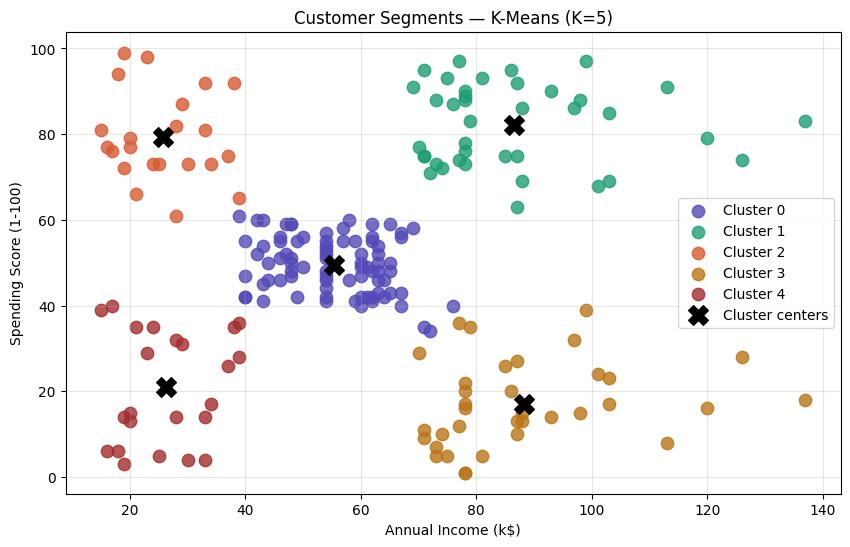

In [9]:
colors = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#A32D2D']
labels_text = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(10, 6))

for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors[i], label=labels_text[i],
        s=80, alpha=0.8
    )

# Plot cluster centers
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c='black', marker='X', s=200,
    label='Cluster centers', zorder=5
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments — K-Means (K=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# What does each cluster actually represent?
segment_names = {}

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    avg_income = cluster_data['Annual Income (k$)'].mean()
    avg_spending = cluster_data['Spending Score (1-100)'].mean()
    avg_age = cluster_data['Age'].mean()
    size = len(cluster_data)

    # Classify based on income and spending
    if avg_income > 70 and avg_spending > 60:
        name = "High income, high spenders (Target!)"
    elif avg_income > 70 and avg_spending < 40:
        name = "High income, low spenders (Untapped)"
    elif avg_income < 40 and avg_spending > 60:
        name = "Low income, high spenders (Risky)"
    elif avg_income < 40 and avg_spending < 40:
        name = "Low income, low spenders (Budget)"
    else:
        name = "Average customers (Middle)"

    segment_names[i] = name
    print(f"Cluster {i}: {name}")
    print(f"  Size: {size} customers")
    print(f"  Avg income: ${avg_income:.0f}k")
    print(f"  Avg spending score: {avg_spending:.0f}/100")
    print(f"  Avg age: {avg_age:.0f}")
    print()

Cluster 0: Average customers (Middle)
  Size: 81 customers
  Avg income: $55k
  Avg spending score: 50/100
  Avg age: 43

Cluster 1: High income, high spenders (Target!)
  Size: 39 customers
  Avg income: $87k
  Avg spending score: 82/100
  Avg age: 33

Cluster 2: Low income, high spenders (Risky)
  Size: 22 customers
  Avg income: $26k
  Avg spending score: 79/100
  Avg age: 25

Cluster 3: High income, low spenders (Untapped)
  Size: 35 customers
  Avg income: $88k
  Avg spending score: 17/100
  Avg age: 41

Cluster 4: Low income, low spenders (Budget)
  Size: 23 customers
  Avg income: $26k
  Avg spending score: 21/100
  Avg age: 45



Explained variance per component:
  PC1: 33.7%
  PC2: 26.2%
  Total: 59.9% of information kept


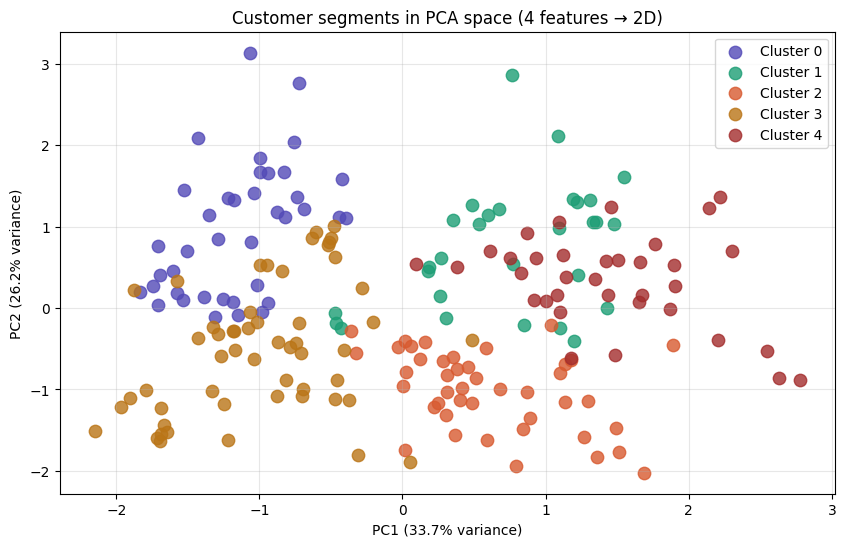

Adjusted Rand Index: 0.942


In [14]:
# Now use ALL 4 features (Age, Income, Spending + Gender encoded)
df['Genre_encoded'] = (df['Genre'] == 'Female').astype(int)

X_full = df[['Age', 'Annual Income (k$)',
             'Spending Score (1-100)', 'Genre_encoded']].values

X_full_scaled = StandardScaler().fit_transform(X_full)

# Reduce 4D → 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full_scaled)

print("Explained variance per component:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}% of information kept")

# Train K-means on full 4D data
kmeans_full = KMeans(n_clusters=5, n_init=10, random_state=42)
clusters_full = kmeans_full.fit_predict(X_full_scaled)

# Plot in PCA space
plt.figure(figsize=(10, 6))
for i in range(5):
    mask = clusters_full == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=80, alpha=0.8)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer segments in PCA space (4 features → 2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(kmeans_labels, hier_labels)
print(f"Adjusted Rand Index: {ari:.3f}")
# Score near 1.0 = algorithms agree on which customers belong together
# Score near 0.0 = completely different groupings

PCA component loadings:
(Higher absolute value = feature contributes more to that PC)

       Age  Annual Income  Spending Score  Gender
PC1  0.688         -0.006          -0.687  -0.234
PC2 -0.104          0.765           0.103  -0.627


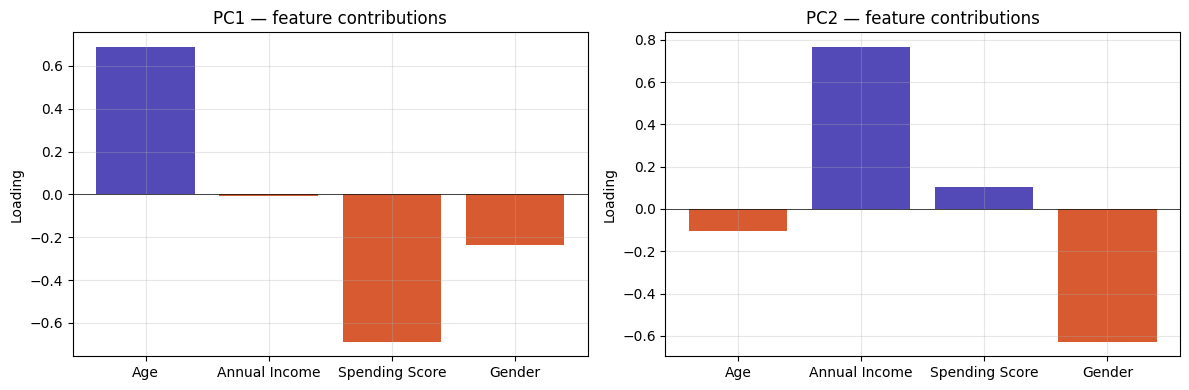

In [12]:
# PCA components tell you which features each PC represents
feature_names = ['Age', 'Annual Income', 'Spending Score', 'Gender']
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2']
)

print("PCA component loadings:")
print("(Higher absolute value = feature contributes more to that PC)")
print()
print(components_df.round(3))

# Visualise loadings
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, pc in enumerate(['PC1', 'PC2']):
    values = components_df.loc[pc]
    colors_bar = ['#534AB7' if v > 0 else '#D85A30' for v in values]
    axes[idx].bar(feature_names, values, color=colors_bar)
    axes[idx].set_title(f'{pc} — feature contributions')
    axes[idx].set_ylabel('Loading')
    axes[idx].axhline(y=0, color='black', linewidth=0.5)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()from scipy.cluster.hierarchy import dendrogram, linkage

# Use a sample of 50 customers for readable dendrogram
sample_idx = np.random.choice(len(X_scaled), 50, replace=False)
X_sample = X_scaled[sample_idx]

# Build linkage matrix
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
dendrogram(Z, truncate_mode='level', p=4, color_threshold=3)
plt.title('Hierarchical clustering dendrogram')
plt.xlabel('Customer index')
plt.ylabel('Distance')
plt.axhline(y=3, color='red', linestyle='--', label='Cut here for 5 clusters')
plt.legend()

# Hierarchical with 5 clusters
plt.subplot(1, 2, 2)
hier = AgglomerativeClustering(n_clusters=5, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

for i in range(5):
    mask = hier_labels == i
    plt.scatter(X[mask, 0], X[mask, 1],
                c=colors[i], label=f'Cluster {i}', s=80, alpha=0.8)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hierarchical clustering (Ward, K=5)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare
kmeans_labels = df['Cluster'].values
agreement = np.mean(kmeans_labels == hier_labels)
print(f"\nK-means vs Hierarchical agreement: {agreement*100:.1f}%")
print("(Not 100% because cluster numbering may differ)")

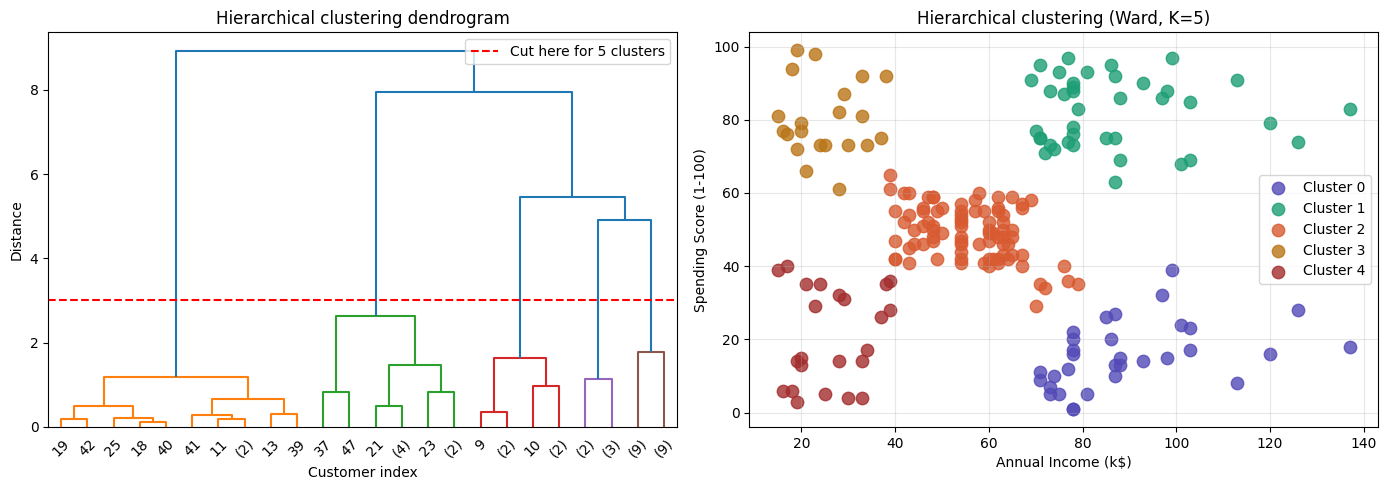


K-means vs Hierarchical agreement: 31.5%
(Not 100% because cluster numbering may differ)


In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a sample of 50 customers for readable dendrogram
sample_idx = np.random.choice(len(X_scaled), 50, replace=False)
X_sample = X_scaled[sample_idx]

# Build linkage matrix
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
dendrogram(Z, truncate_mode='level', p=4, color_threshold=3)
plt.title('Hierarchical clustering dendrogram')
plt.xlabel('Customer index')
plt.ylabel('Distance')
plt.axhline(y=3, color='red', linestyle='--', label='Cut here for 5 clusters')
plt.legend()

# Hierarchical with 5 clusters
plt.subplot(1, 2, 2)
hier = AgglomerativeClustering(n_clusters=5, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

for i in range(5):
    mask = hier_labels == i
    plt.scatter(X[mask, 0], X[mask, 1],
                c=colors[i], label=f'Cluster {i}', s=80, alpha=0.8)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hierarchical clustering (Ward, K=5)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare
kmeans_labels = df['Cluster'].values
agreement = np.mean(kmeans_labels == hier_labels)
print(f"\nK-means vs Hierarchical agreement: {agreement*100:.1f}%")
print("(Not 100% because cluster numbering may differ)")